In [ ]:
# Step 1: Setup and Data Download (Kaggle API)
# This block installs the necessary libraries, asks to upload the kaggle.json, and downloads the dataset directly.

# 1.1 Install Kaggle
!pip install -q kaggle   #Installs the Kaggle library Quitely /silently (without text output) so we can use its commands.

# 1.2 Upload kaggle.json
from google.colab import files   #Imports the Google Colab tool specifically needed to upload files from your computer.
import os   #Imports the standard Python module for interacting with the operating system (standard setup).

print("Please upload your kaggle.json file:")
uploaded = files.upload()   #Triggers the "Choose Files" button that lets you select and upload your kaggle.json file.

# 1.3 Move kaggle.json to the correct directory and set permissions
!mkdir -p ~/.kaggle   #Creates a hidden folder named .kaggle to store your API credentials (if it doesn't exist).
!cp "kaggle (2).json" ~/.kaggle/kaggle.json   # Copies the kaggle.json file you just uploaded into that required configuration folder.
!chmod 600 ~/.kaggle/kaggle.json   #Locks the file permissions so only you can read it (a security requirement for the API

# 1.4 Download and Unzip the dataset = downloading the data from Kaggle directly to Google Colab
# Dataset: https://www.kaggle.com/datasets/redwankarimsony/heart-disease-data
!kaggle datasets download -d redwankarimsony/heart-disease-data   # Uses the API to download the compresse
!unzip -o heart-disease-data.zip    # -o overwrites if exists & Extracts the raw CSV files from the downlo
print("\nDataset downloaded and extracted successfully!")

Please upload your kaggle.json file:


Saving kaggle (2).json to kaggle (2).json
Dataset URL: https://www.kaggle.com/datasets/redwankarimsony/heart-disease-data
License(s): copyright-authors
  0% 0.00/12.4k [00:00<?, ?B/s]
100% 12.4k/12.4k [00:00<00:00, 49.8MB/s]
Archive:  heart-disease-data.zip
  inflating: heart_disease_uci.csv   

Dataset downloaded and extracted successfully!


In [ ]:
import pandas as pd
import numpy as np
file_path='heart_disease_uci.csv'
data=pd.read_csv(file_path)
print("Original Data Shape: ",data.shape)
print("\nMissing Values:\n",data.isnull().sum())
data['target']=data['num'].apply(lambda x:1 if x>0 else 0)
data=data.drop(['id','dataset','num'],axis=1)
print("\nTarget distribution:\n",data['target'].value_counts())
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler,OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

Original Data Shape:  (920, 16)

Missing Values:
 id            0
age           0
sex           0
dataset       0
cp            0
trestbps     59
chol         30
fbs          90
restecg       2
thalch       55
exang        55
oldpeak      62
slope       309
ca          611
thal        486
num           0
dtype: int64

Target distribution:
 target
1    509
0    411
Name: count, dtype: int64


In [ ]:
# Step 3: Improved Preprocessing
# An "Imputer" is added to handle missing values automatically
# (replacing them with the median for numerical features or the most frequent value for categorical features)
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

In [ ]:
# 3.1 Define Features
# Separate features and target
X = data.drop('target', axis=1)
y = data['target']
# Identify categorical and numerical columns automatically
categorical_features = X.select_dtypes(include=['object', 'category']).columns.tolist()
numerical_features = X.select_dtypes(include=['int64', 'float64']).columns.tolist()
print(f"Categorical: {categorical_features}")
print(f"Numerical: {numerical_features}")

# 3.2 Create Pipelines for Preprocessing
# Numerical: Impute missing values with Median -> Scale
# Automatically finds and lists the names of all columns that contain numbers
numeric_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

# Categorical: Impute missing with 'most_frequent' and OneHotEncode
categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('encoder', OneHotEncoder(handle_unknown='ignore'))
])
preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, numerical_features),
        ('cat', categorical_transformer, categorical_features)
    ])
# 3.4 Split Data
#Splits the data: 80% for training and 20% for testing, while keeping the ratio of sick/healthy patches
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# 3.5 Apply Preprocessing
X_train_transformed = preprocessor.fit_transform(X_train)
X_test_transformed = preprocessor.transform(X_test)

# Convert to dense array if the result is a sparse matrix (often needed for Neural Networks)
if hasattr(X_train_transformed, 'toarray'):
    X_train_transformed = X_train_transformed.toarray()
    X_test_transformed = X_test_transformed.toarray()

print(f"Processed Feature Shape: {X_train_transformed.shape}")

Categorical: ['sex', 'cp', 'fbs', 'restecg', 'exang', 'slope', 'thal']
Numerical: ['age', 'trestbps', 'chol', 'thalch', 'oldpeak', 'ca']
Processed Feature Shape: (736, 25)


In [ ]:
# Step 4: Building One Improved Neural Network
# Improvements Added: (1) Dropout Layers: To prevent overfitting.
# (2) Batch Normalization: To stabilize learning and speed up convergence.
# (3) Layer Structure: A slightly deeper architecture suitable for this feature set.

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, BatchNormalization
from tensorflow.keras.optimizers import Adam  # A popular algorithm for training

def build_model(input_dim):
    # Defines a reusable function that builds the neural net
    model = Sequential([
        # Input Layer
        Dense(64, input_dim=input_dim, activation='relu'),
        BatchNormalization(),
        Dropout(0.3),  # Drops 30% of neurons randomly to prevent overfitting

        # Hidden Layer 1
        Dense(32, activation='relu'),
        BatchNormalization(),
        Dropout(0.3),

        # Hidden Layer 2
        Dense(16, activation='relu'),

        # Output Layer (Sigmoid for Binary Classification)
        Dense(1, activation='sigmoid')
    ])
    model.compile(optimizer=Adam(learning_rate=0.001),
              loss='binary_crossentropy',

              metrics=['accuracy'])

    return model

model = build_model(X_train_transformed.shape[1])
model.summary()


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 64)             │         1,664 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 64)             │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 32)             │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,673 (18.25 KB)

 Trainable params: 4,481 (17.50 KB)

 Non-trainable params: 192 (768.00 B)

In [ ]:
# Step 5: Train with Callbacks
# Improvements Added:
# (1) EarlyStopping: Stops training if the validation loss stops improving
# (saves time and prevents overfitting)
# (2) ReduceLROnPlateau: Slows the learning rate if the model gets stuck.

from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau  # Imports tools to automatically adjust or stop the training

# Define callbacks
early_stopping = EarlyStopping(  # Initializes a mechanism to halt training early if the model stops learning.
    monitor='val_loss',  # Watches the validation loss (error on unseen data) to decide when to stop.
    patience=10,  # Waits for 10 epochs (rounds) of no improvement before actually stopping.
    restore_best_weights=True,  # Ensures that when training stops, the model reverts to its best-performing version, not the latest.
    verbose=1  # Prints a message to the console when early stopping is triggered so you know why it stopped.
)

reduce_lr = ReduceLROnPlateau(  # Initializes a tool to slow down the learning rate if progress stalls (helps fine-tune the model).
    monitor='val_loss',  # Watches the validation loss to decide when to adjust the learning rate.
    factor=0.2,  # Reduces the learning rate to 20% of its current value (e.g., from 0.01 to 0.002) when triggered.
    patience=5,  # Waits for 5 epochs of no improvement before reducing the learning rate.
    min_lr=0.00001,  # Sets a floor so the learning rate never goes below this value.
    verbose=1  # Prints a message whenever the learning rate gets reduced.

)

# Train the model
history = model.fit(
    X_train_transformed, y_train,
    validation_split=0.2,
    epochs=100,
    batch_size=32,
    callbacks=[early_stopping, reduce_lr],
    verbose=1
)

Epoch 1/100
19/19 ━━━━━━━━━━━━━━━━━━━━ 4s 31ms/step - accuracy: 0.5379 - loss: 0.7639 - val_accuracy: 0.7635 - val_loss: 0.6340 - learning_rate: 0.0010
Epoch 2/100
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.6621 - loss: 0.6158 - val_accuracy: 0.7703 - val_loss: 0.5867 - learning_rate: 0.0010
Epoch 3/100
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.7158 - loss: 0.5505 - val_accuracy: 0.7770 - val_loss: 0.5511 - learning_rate: 0.0010
Epoch 4/100
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.7695 - loss: 0.4844 - val_accuracy: 0.7770 - val_loss: 0.5225 - learning_rate: 0.0010
Epoch 5/100
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.7890 - loss: 0.4759 - val_accuracy: 0.7905 - val_loss: 0.4992 - learning_rate: 0.0010
Epoch 6/100
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.7978 - loss: 0.4493 - val_accuracy: 0.7973 - val_loss: 0.4795 - learning_rate: 0.0010
Epoch 7/100
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.8092 - loss: 0.4661 - val_ac

6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 0.8198 - loss: 0.3991
Test Accuracy: 84.78%
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step
              precision    recall  f1-score   support

           0       0.86      0.78      0.82        82
           1       0.84      0.90      0.87       102

    accuracy                           0.85       184
   macro avg       0.85      0.84      0.84       184
weighted avg       0.85      0.85      0.85       184



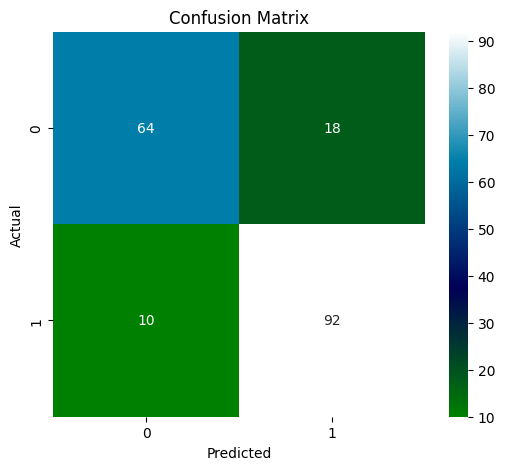

In [ ]:
# STEP 6: Evaluation
import matplotlib.pyplot as plt
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns

loss, accuracy = model.evaluate(X_test_transformed, y_test)
print(f"Test Accuracy: {accuracy*100:.2f}%")

y_pred_prob = model.predict(X_test_transformed)
y_pred = (y_pred_prob > 0.5).astype(int)

print(classification_report(y_test, y_pred))

plt.figure(figsize=(6, 5))
sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt='d', cmap='ocean')
plt.title('Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

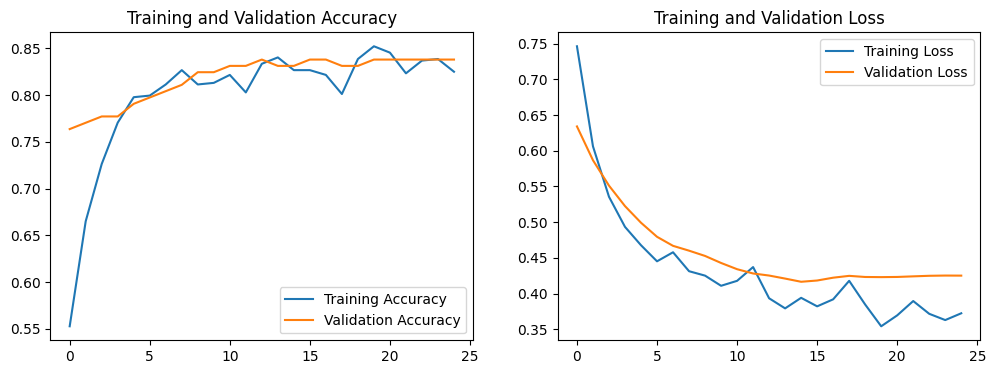

In [ ]:
# STEP 7: Plot Training History
def plot_history(history):
    acc = history.history['accuracy']
    val_acc = history.history['val_accuracy']
    loss = history.history['loss']
    val_loss = history.history['val_loss']
    epochs_range = range(len(acc))

    plt.figure(figsize=(12, 4))

    plt.subplot(1, 2, 1)
    plt.plot(epochs_range, acc, label='Training Accuracy')
    plt.plot(epochs_range, val_acc, label='Validation Accuracy')
    plt.legend(loc='lower right')
    plt.title('Training and Validation Accuracy')

    plt.subplot(1, 2, 2)
    plt.plot(epochs_range, loss, label='Training Loss')
    plt.plot(epochs_range, val_loss, label='Validation Loss')
    plt.legend(loc='upper right')
    plt.title('Training and Validation Loss')
    plt.show()

plot_history(history)